<a href="https://colab.research.google.com/github/sandamali-2002/4th-sem/blob/main/cat_dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy -q
!pip install pandas -q
!pip install matplotlib -q
!pip install tensorflow -q
!pip install opendatasets -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import opendatasets as od

In [ ]:
od.download("https://www.kaggle.com/datasets/dineshpiyasamara/cats-and-dogs-for-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: chandimasandamali
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/dineshpiyasamara/cats-and-dogs-for-classification


100%|██████████| 217M/217M [00:00<00:00, 902MB/s] 


In [ ]:
batch_size=32
image_size=(128,128)

In [ ]:
train_data_dir="/content/cats-and-dogs-for-classification/cats_dogs/train"
test_data_dir="/content/cats-and-dogs-for-classification/cats_dogs/test"

In [ ]:
train_data=tf.keras.utils.image_dataset_from_directory(train_data_dir,
                                                       batch_size=batch_size,
                                                       image_size=image_size,
                                                       subset="training",
                                                       validation_split=0.1,
                                                       seed=42)

Found 8000 files belonging to 2 classes.
Using 7200 files for training.


In [ ]:
validation_data=tf.keras.utils.image_dataset_from_directory(train_data_dir,
                                                      batch_size=batch_size,
                                                      image_size=image_size,
                                                      subset="validation",
                                                      validation_split=0.1,
                                                      seed=42)

Found 8000 files belonging to 2 classes.
Using 800 files for validation.


In [ ]:
test_data=tf.keras.utils.image_dataset_from_directory( test_data_dir,
                                                      batch_size=batch_size,
                                                       image_size=image_size,
                                                       )

Found 2000 files belonging to 2 classes.


In [ ]:
class_names=train_data.class_names
class_names

['cats', 'dogs']

In [ ]:
for image_batch,label_batch in train_data.take(1):
  print(image_batch.shape)
  print(label_batch.shape)


(32, 128, 128, 3)
(32,)


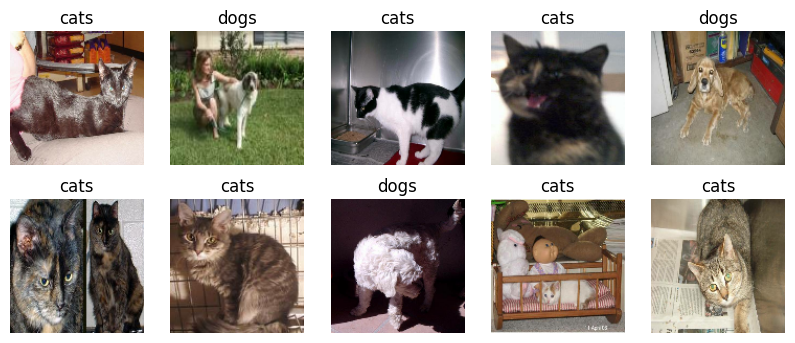

In [ ]:
#plot data samples
plt.figure(figsize=(10,4))
for image,label in train_data.take(1):
  for i in range(10):
    ax=plt.subplot(2,5,i+1)
    plt.imshow(image[i].numpy().astype("uint8"))
    plt.title(class_names[label[i]])
    plt.axis('off')

In [ ]:
for image,label in train_data.take(1):
  for i in range(1):
    print(image)

tf.Tensor(
[[[[101.00769   104.00769   109.00769  ]
   [111.074585  112.71521   114.30505  ]
   [117.635284  115.31354   112.59396  ]
   ...
   [129.86246   132.91324   136.22964  ]
   [126.8725    133.10297   135.69281  ]
   [128.9002    138.99207   139.94614  ]]

  [[ 85.20029    88.20029    93.20029  ]
   [ 99.3725     99.79227   101.78906  ]
   [114.00287   112.997925  110.048706 ]
   ...
   [116.720825  120.720825  123.720825 ]
   [119.9389    126.16937   128.75922  ]
   [138.79547   147.0824    148.93893  ]]

  [[ 92.54297    94.90234    99.58203  ]
   [ 91.57605    91.986206   93.986206 ]
   [105.38388   104.38388   101.75107  ]
   ...
   [120.73743   125.52237   128.52237  ]
   [130.21445   135.21445   138.21445  ]
   [127.32648   134.36554   136.68585  ]]

  ...

  [[118.07504   122.07504   125.07504  ]
   [121.617584  125.617584  128.61758  ]
   [130.54602   134.54602   137.54602  ]
   ...
   [ 81.51825    87.02301    96.76108  ]
   [ 45.951294   50.819916   54.147003 ]
   [ 

In [ ]:
#normalizing


train_data=train_data.map(lambda x,y:(x/255,y))
validation_data=validation_data.map(lambda x,y:(x/255,y))
test_data=test_data.map(lambda x,y:(x/255,y))

In [ ]:
for image,label in train_data.take(1):
  print(image)

tf.Tensor(
[[[[0.15117954 0.08451287 0.12372855]
   [0.1564951  0.08982843 0.12904412]
   [0.14387254 0.07720588 0.11642157]
   ...
   [0.         0.00392157 0.        ]
   [0.         0.         0.        ]
   [0.         0.         0.        ]]

  [[0.15078124 0.08411458 0.12333027]
   [0.1463848  0.07971814 0.11893383]
   [0.13852635 0.07185968 0.11107536]
   ...
   [0.         0.         0.        ]
   [0.         0.00127145 0.        ]
   [0.         0.         0.        ]]

  [[0.15681386 0.09014719 0.12936288]
   [0.15010071 0.08343404 0.12264973]
   [0.1491728  0.08250613 0.12172181]
   ...
   [0.00392157 0.         0.        ]
   [0.         0.00392157 0.        ]
   [0.         0.         0.        ]]

  ...

  [[0.7237403  0.6738876  0.726761  ]
   [0.7528033  0.7035823  0.75956535]
   [0.77319306 0.71951526 0.7698836 ]
   ...
   [0.04705882 0.00392157 0.03529412]
   [0.05098039 0.         0.03529412]
   [0.0395804  0.         0.03137255]]

  [[0.7596398  0.66668636 0.694030

In [ ]:
#data augmentation
data_augmentation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal",input_shape=(128,128,3)),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
                                   ]   )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model=tf.keras.Sequential()
model.add(data_augmentation)

model.add(tf.keras.layers.Conv2D(32,(3,3),activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(2,2))

model.add(tf.keras.layers.Conv2D(64,(3,3),activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(2,2))

model.add(tf.keras.layers.Conv2D(128,(3,3),activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(2,2))

model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(128,activation='relu'))
model.add(tf.keras.layers.Dense(128,activation='relu'))
model.add(tf.keras.layers.Dense(32,activation='relu'))
model.add(tf.keras.layers.Dense(1,activation='sigmoid'))



In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,325,825 (12.69 MB)

 Trainable params: 3,325,569 (12.69 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
import time

start_time = time.time()

history = model.fit(train_data,
                    epochs=20,
                    validation_data=validation_data)

end_time = time.time()



Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5950 - loss: 0.6694 - val_accuracy: 0.6450 - val_loss: 0.6775
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.6599 - loss: 0.6134 - val_accuracy: 0.6137 - val_loss: 0.7067
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.6827 - loss: 0.5920 - val_accuracy: 0.6087 - val_loss: 0.7112
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.7254 - loss: 0.5415 - val_accuracy: 0.6850 - val_loss: 0.6111
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.7383 - loss: 0.5219 - val_accuracy: 0.7750 - val_loss: 0.4722
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.7523 - loss: 0.4993 - val_accuracy: 0.7300 - val_loss: 0.6596
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.7677 - loss: 0.4737 - val_accuracy: 0.7775 - val_loss: 0.4593
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7868 - loss: 0.4457 - va

In [ ]:
history.history

{'accuracy': [0.6186110973358154,
  0.660277783870697,
  0.6974999904632568,
  0.7283333539962769,
  0.7498611211776733,
  0.7620833516120911,
  0.7745833396911621,
  0.7863888740539551,
  0.7961111068725586,
  0.7995833158493042,
  0.8106944561004639,
  0.8151388764381409,
  0.8204166889190674,
  0.8320833444595337,
  0.8376389145851135,
  0.8452777862548828,
  0.8541666865348816,
  0.8581944704055786,
  0.8611111044883728,
  0.8637499809265137],
 'loss': [0.6505465507507324,
  0.6136870384216309,
  0.5731093287467957,
  0.5339077711105347,
  0.5122891664505005,
  0.4919052720069885,
  0.47029584646224976,
  0.4471333920955658,
  0.4384098947048187,
  0.4225109815597534,
  0.41240888833999634,
  0.40168049931526184,
  0.38580119609832764,
  0.37022122740745544,
  0.3583866059780121,
  0.3518816828727722,
  0.33781418204307556,
  0.3287872076034546,
  0.32130277156829834,
  0.3100006878376007],
 'val_accuracy': [0.6449999809265137,
  0.6137499809265137,
  0.6087499856948853,
  0.685000

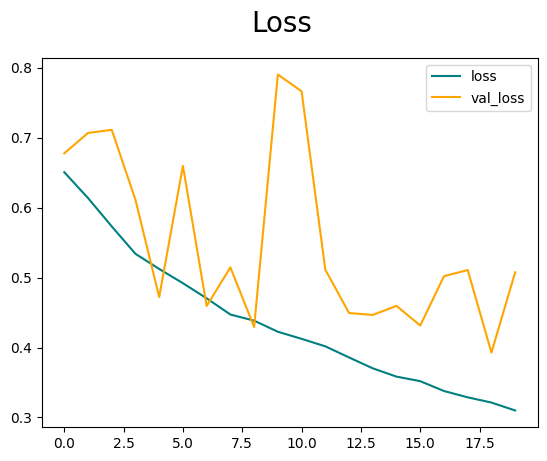

In [ ]:
fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='loss')
plt.plot(history.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend()
plt.show()

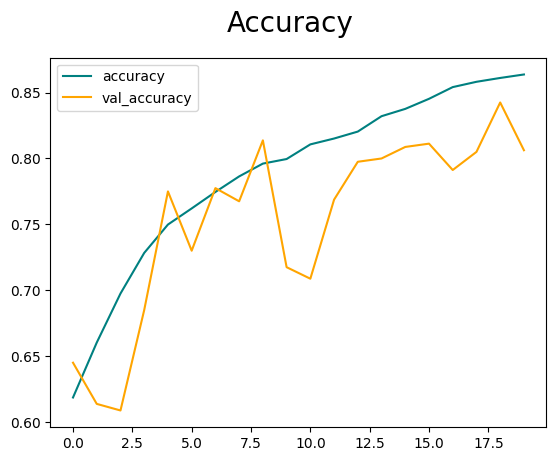

In [ ]:
fig = plt.figure()
plt.plot(history.history['accuracy'], color='teal', label='accuracy')
plt.plot(history.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend()
plt.show()

In [ ]:
precision = tf.keras.metrics.Precision()
recall = tf.keras.metrics.Recall()
accuracy = tf.keras.metrics.BinaryAccuracy()

In [ ]:
for batch in test_data.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    precision.update_state(y, yhat)
    recall.update_state(y, yhat)
    accuracy.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━

In [ ]:
precision.result()

<tf.Tensor: shape=(), dtype=float32, numpy=0.9163346886634827>

In [ ]:
recall.result()

<tf.Tensor: shape=(), dtype=float32, numpy=0.6899999976158142>

In [ ]:
accuracy.result()

<tf.Tensor: shape=(), dtype=float32, numpy=0.8134999871253967>

In [ ]:
!pip install opencv.python

In [ ]:
import cv2

In [ ]:
image=cv2.imread("/content/cats-and-dogs-for-classification/cats_dogs/test/cats/cat.4009.jpg")

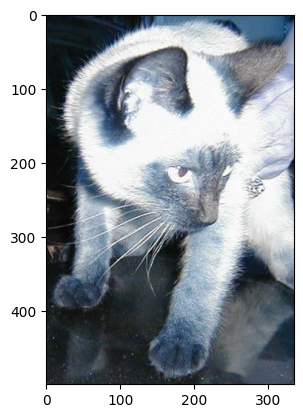

In [ ]:
plt.imshow(image)
plt.show()

In [ ]:
resized_image=tf.image.resize(image,image_size)
scale_image=resized_image/255

In [ ]:
scale_image

<tf.Tensor: shape=(128, 128, 3), dtype=float32, numpy=
array([[[0.05241723, 0.08415743, 0.09806674],
        [0.05565856, 0.08739875, 0.10130807],
        [0.05891568, 0.09065588, 0.10456519],
        ...,
        [0.07607374, 0.19781087, 0.28050083],
        [0.06560034, 0.171532  , 0.22886029],
        [0.07835143, 0.17105976, 0.2120524 ]],

       [[0.05820145, 0.08032155, 0.07639998],
        [0.0552416 , 0.0773617 , 0.07344013],
        [0.05238971, 0.07450981, 0.07058824],
        ...,
        [0.04635417, 0.14355014, 0.24894302],
        [0.02139222, 0.09618039, 0.17336306],
        [0.02369864, 0.08102094, 0.13671014]],

       [[0.05536152, 0.0855239 , 0.09070136],
        [0.05989512, 0.08730014, 0.09499081],
        [0.05439645, 0.07555147, 0.08893876],
        ...,
        [0.05522724, 0.1608633 , 0.3032947 ],
        [0.06712694, 0.1548888 , 0.28169566],
        [0.20370688, 0.27061865, 0.39059412]],

       ...,

       [[0.14663038, 0.14975537, 0.17224313],
        [0.11

In [ ]:
np.expand_dims(scale_image,0).shape

(1, 128, 128, 3)

In [ ]:
y_hat=model.predict(np.expand_dims(scale_image,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step


In [ ]:
y_hat

array([[0.08578262]], dtype=float32)

In [ ]:
if y_hat >=0.5:
  print(class_names[1])
else:
  print(class_names[0])



cats
